Device: cuda
obs_dim, n_actions: 4 2
[REINFORCE] Ep 1/3000  Return: 10.0  20-avg: 10.0
[REINFORCE] Ep 20/3000  Return: 19.0  20-avg: 21.1
[REINFORCE] Ep 40/3000  Return: 21.0  20-avg: 20.9
[REINFORCE] Ep 60/3000  Return: 27.0  20-avg: 32.1
[REINFORCE] Ep 80/3000  Return: 59.0  20-avg: 27.4
[REINFORCE] Ep 100/3000  Return: 14.0  20-avg: 30.2
[REINFORCE] Ep 120/3000  Return: 26.0  20-avg: 26.9
[REINFORCE] Ep 140/3000  Return: 41.0  20-avg: 35.5
[REINFORCE] Ep 160/3000  Return: 18.0  20-avg: 33.5
[REINFORCE] Ep 180/3000  Return: 17.0  20-avg: 29.4
[REINFORCE] Ep 200/3000  Return: 93.0  20-avg: 29.2
[REINFORCE] Ep 220/3000  Return: 58.0  20-avg: 28.7
[REINFORCE] Ep 240/3000  Return: 26.0  20-avg: 35.5
[REINFORCE] Ep 260/3000  Return: 34.0  20-avg: 37.4
[REINFORCE] Ep 280/3000  Return: 36.0  20-avg: 34.0
[REINFORCE] Ep 300/3000  Return: 63.0  20-avg: 42.8
[REINFORCE] Ep 320/3000  Return: 14.0  20-avg: 41.5
[REINFORCE] Ep 340/3000  Return: 38.0  20-avg: 43.4
[REINFORCE] Ep 360/3000  Return: 

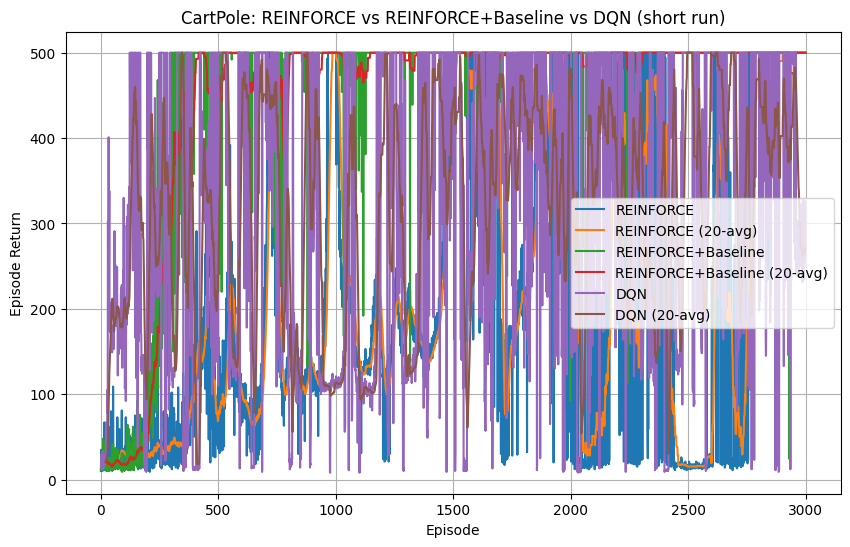

REINFORCE: mean=221.80, std=184.35, last10_mean=500.00
REINFORCE+Baseline: mean=449.90, std=132.85, last10_mean=500.00
DQN: mean=318.75, std=176.06, last10_mean=278.90


In [2]:
# CartPole comparison: REINFORCE, REINFORCE+baseline, and DQN
# Copy this cell into a Jupyter notebook or Google Colab and run.
# If you use Colab, install gymnasium or gym first (see instructions below).

import math, random, time
from collections import deque, namedtuple
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
GYM_VER = "gymnasium"  # change to "gym" if using OpenAI Gym
ENV_NAME = "CartPole-v1"
env = gym.make(ENV_NAME)

obs_dim = env.observation_space.shape[0]  # should be 4
n_actions = env.action_space.n           # should be 2

# ========== Hyperparameters ==========
EPISODES = 3000         # increase for better convergence
MAX_STEPS = 500
GAMMA = 0.99
LR_POLICY = 1e-3
LR_VALUE = 1e-3
LR_DQN = 1e-3
BATCH_SIZE = 64
REPLAY_SIZE = 5000
TARGET_UPDATE_FREQ = 100  # gradient steps
print("obs_dim, n_actions:", obs_dim, n_actions)

# ========== Networks ==========
class PolicyNet(nn.Module):
    def __init__(self, s_dim, a_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, a_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, s_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class QNet(nn.Module):
    def __init__(self, s_dim, a_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, a_dim)
        )
    def forward(self, x):
        return self.net(x)

# ========== Utilities ==========
def compute_returns(rewards, gamma=GAMMA):
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return np.array(returns, dtype=np.float32)


# ========== REINFORCE training ==========
def train_reinforce(env, episodes=EPISODES, baseline=False):
    policy = PolicyNet(obs_dim, n_actions).to(device)
    optimizer_policy = optim.Adam(policy.parameters(), lr=LR_POLICY)
    value_net = None
    optimizer_value = None
    if baseline:
        value_net = ValueNet(obs_dim).to(device)
        optimizer_value = optim.Adam(value_net.parameters(), lr=LR_VALUE)

    episode_returns = []
    for ep in range(episodes):
        state, _ = env.reset(seed=SEED+ep) if GYM_VER=="gymnasium" else (env.reset(), None)
        states, actions, rewards = [], [], []
        for t in range(MAX_STEPS):
            s_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            logits = policy(s_t)
            probs = torch.softmax(logits, dim=-1)
            m = torch.distributions.Categorical(probs)
            a = m.sample().item()
            step_out = env.step(a)
            # gymnasium returns (next_state, reward, terminated, truncated, info)
            if GYM_VER=="gymnasium":
                next_state, r, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                next_state, r, done, info = step_out
            states.append(state)
            actions.append(a)
            rewards.append(r)
            state = next_state
            if done:
                break

        returns = compute_returns(rewards)
        episode_return = sum(rewards)
        episode_returns.append(episode_return)

        # Convert to tensors for update
        states_v = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions_v = torch.tensor(actions, dtype=torch.int64, device=device)
        returns_v = torch.tensor(returns, dtype=torch.float32, device=device)

        logits = policy(states_v)
        logp = torch.log_softmax(logits, dim=-1)
        selected_logp = logp[range(len(actions)), actions_v]

        if baseline:
            values = value_net(states_v)
            advantages = returns_v - values.detach()
            policy_loss = -(selected_logp * advantages).mean()
            value_preds = value_net(states_v)
            value_loss = nn.MSELoss()(value_preds, returns_v)
            optimizer_policy.zero_grad()
            optimizer_value.zero_grad()
            policy_loss.backward()
            value_loss.backward()
            optimizer_policy.step()
            optimizer_value.step()
        else:
            policy_loss = -(selected_logp * returns_v).mean()
            optimizer_policy.zero_grad()
            policy_loss.backward()
            optimizer_policy.step()

        if (ep+1) % 20 == 0 or ep==0:
            avg20 = np.mean(episode_returns[-20:])
            print(f"[REINFORCE{'+V' if baseline else ''}] Ep {ep+1}/{episodes}  Return: {episode_return:.1f}  20-avg: {avg20:.1f}")

    return episode_returns


# ========== Simple DQN ==========
Transition = namedtuple('Transition', ('s','a','r','s2','done'))
class ReplayBuffer:
    def __init__(self, capacity=REPLAY_SIZE):
        self.buffer = deque(maxlen=capacity)
    def add(self, *args):
        self.buffer.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        s = torch.tensor(np.vstack([b.s for b in batch]), dtype=torch.float32, device=device)
        a = torch.tensor([b.a for b in batch], dtype=torch.int64, device=device)
        r = torch.tensor([b.r for b in batch], dtype=torch.float32, device=device)
        s2 = torch.tensor(np.vstack([b.s2 for b in batch]), dtype=torch.float32, device=device)
        done = torch.tensor([b.done for b in batch], dtype=torch.float32, device=device)
        return s,a,r,s2,done
    def __len__(self):
        return len(self.buffer)

def train_dqn(env, episodes=EPISODES):
    qnet = QNet(obs_dim, n_actions).to(device)
    target = QNet(obs_dim, n_actions).to(device)
    target.load_state_dict(qnet.state_dict())
    optimizer = optim.Adam(qnet.parameters(), lr=LR_DQN)
    buffer = ReplayBuffer()
    eps_start, eps_end, eps_decay = 1.0, 0.02, 500.0
    total_steps = 0
    episode_returns = []

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED+100+ep) if GYM_VER=="gymnasium" else (env.reset(), None)
        ep_return = 0.0
        for t in range(MAX_STEPS):
            eps = eps_end + (eps_start - eps_end) * math.exp(-1.0 * total_steps / eps_decay)
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s_v = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    qvals = qnet(s_v)
                    action = int(qvals.argmax().item())
            step_out = env.step(action)
            if GYM_VER=="gymnasium":
                next_state, reward, terminated, truncated, _ = step_out
                done = terminated or truncated
            else:
                next_state, reward, done, _ = step_out
            ep_return += reward
            buffer.add(state, action, reward, next_state, float(done))
            state = next_state
            total_steps += 1

            # learn
            if len(buffer) >= 64:
                s,a,r,s2,done_mask = buffer.sample(BATCH_SIZE)
                qvals = qnet(s).gather(1, a.unsqueeze(-1)).squeeze(-1)
                with torch.no_grad():
                    q_next = target(s2).max(1)[0]
                    q_target = r + (1.0 - done_mask) * GAMMA * q_next
                loss = nn.MSELoss()(qvals, q_target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if total_steps % TARGET_UPDATE_FREQ == 0:
                target.load_state_dict(qnet.state_dict())

            if done:
                break
        episode_returns.append(ep_return)
        if (ep+1) % 20 == 0 or ep==0:
            avg20 = np.mean(episode_returns[-20:])
            print(f"[DQN] Ep {ep+1}/{episodes}  Return: {ep_return:.1f}  20-avg: {avg20:.1f}")
    return episode_returns


# ========== Run experiments (short) ==========
start = time.time()
returns_reinforce = train_reinforce(env, episodes=EPISODES, baseline=False)
returns_reinforce_v = train_reinforce(env, episodes=EPISODES, baseline=True)
returns_dqn = train_dqn(env, episodes=EPISODES)
print("Total training time (s):", time.time() - start)

# ========== Plotting ==========
def smooth(x, w=20):
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(10,6))
plt.plot(returns_reinforce, label='REINFORCE')
plt.plot(np.arange(len(returns_reinforce)-19)+19, smooth(returns_reinforce), label='REINFORCE (20-avg)')
plt.plot(returns_reinforce_v, label='REINFORCE+Baseline')
plt.plot(np.arange(len(returns_reinforce_v)-19)+19, smooth(returns_reinforce_v), label='REINFORCE+Baseline (20-avg)')
plt.plot(returns_dqn, label='DQN')
plt.plot(np.arange(len(returns_dqn)-19)+19, smooth(returns_dqn), label='DQN (20-avg)')
plt.xlabel("Episode")
plt.ylabel("Episode Return")
plt.title("CartPole: REINFORCE vs REINFORCE+Baseline vs DQN (short run)")
plt.legend()
plt.grid(True)
plt.show()

# ========== Summary stats ==========
def summarize(name, returns):
    return f"{name}: mean={np.mean(returns):.2f}, std={np.std(returns):.2f}, last10_mean={np.mean(returns[-10:]):.2f}"

print(summarize("REINFORCE", returns_reinforce))
print(summarize("REINFORCE+Baseline", returns_reinforce_v))
print(summarize("DQN", returns_dqn))

# Save results for later inspection
#np.savez_compressed("cartpole_comparison_results.npz",
#                    reinforce=returns_reinforce,
#                   reinforce_baseline=returns_reinforce_v,
#                    dqn=returns_dqn)
#print("Saved results to cartpole_comparison_results.npz")
